In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

import matplotlib.pyplot as plt
import seaborn as sns

2026-03-06 05:07:51.872895: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772773672.108044      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772773672.178885      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772773672.750164      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772773672.750223      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772773672.750226      55 computation_placer.cc:177] computation placer alr

Load the datasets

In [15]:
members_df = pd.read_excel(
    "/kaggle/input/datasets/samyukthaanand/dataset/main.xlsx",
    engine="openpyxl",
    nrows=50000
)

txn_df = pd.read_excel(
    "/kaggle/input/datasets/samyukthaanand/dataset/transactions.xlsx",
    engine="openpyxl",
    nrows=200000
)

print(members_df.shape)
print(txn_df.shape)

(50000, 18)
(200000, 24)


Remove Unnecessary Columns

In [16]:
members_df = members_df.drop(columns=[
    "FST_NAME",
    "MID_NAME",
    "LAST_NAME",
    "EMAIL_ADDRESS",
    "MOBILE",
    "VEHICLE_NO"
], errors="ignore")

txn_df = txn_df.drop(columns=[
    "CARD_NUMBER",
    "PHONE_NUMBER",
    "CUSTOMER_NAME"
], errors="ignore")

Merge the two datasets

In [17]:
df = txn_df.merge(members_df, on="MEMBER_ID", how="left")

print("Merged dataset shape:", df.shape)

df.head()

Merged dataset shape: (200000, 32)


,Unnamed: 0_x,STATE_OFFICE,AO_DO,SALES_AREA,RO_NAME,RO_CODE,MERCHANT_ID,TXN_DT_x,TXN_NUM,CHANNEL,...,GENDER,BIRTH_DT,PIN_CODE,VEHICLE_MAKE,VEHICLE_MODEL,FUEL_TYPE,SUPPRESS_FAX_FLG,ON_BOARD_DT,TXN_DT_y,STATUS_CD
0,0,Kerala SO-Retail Sales,Thiruvananthpuram DO-Retail Sales,Pathanamthitta Ret SA,KGG FUELS,193960,470000099208549,2025-12-06 06:12:58,IM39282991061225183058,ITPS,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
1,1,Kerala SO-Retail Sales,Ernakulam (Kochi) DO-Retail Sales,Ernakulam South Ret SA,SREE NARAYANA SALES & SERVICES,125139,30thNo37585153214297,2025-12-17 11:12:05,OC26844147251217112405,OCL,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
2,2,Tamilnadu SO-Retail Sales,Madurai DO-Retail Sales,Virudhunagar Retail SA,PADMAVATHI AUTO SERVICE (LOCK NO.16,185672,470000099036908,2025-12-17 09:12:41,IM39079261171225210641,ITPS,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
3,3,Marketing Head Office-Retail Sales,Marketing Head Office-Retail Sales,Marketing Head Office-Retail Sales,Marketing Head Office-Retail Sales,100,NaN,2025-12-11 09:12:21,11122503000,HDFC_CCC,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN
4,4,Kerala SO-Retail Sales,Ernakulam (Kochi) DO-Retail Sales,Thrissur West RSA,CROWN FUELS,347188,470000099268941,2025-12-24 01:12:14,IM00955889241225132814,ITPS,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaT,NaT,NaN


Convert Data Columns

In [19]:
date_cols = ["TXN_DT", "BIRTH_DT", "ON_BOARD_DT"]

for col in date_cols:
    
    if col in df.columns:
        
        df[col] = pd.to_datetime(df[col], errors="coerce")
        
        df[col] = df[col].astype("int64") // 10**9

Feature Engineering

In [20]:
txn_count = df.groupby("MEMBER_ID").size()

df["txn_frequency"] = df["MEMBER_ID"].map(txn_count)

Sample Dataset

In [21]:
df_sample = df.copy()

print("Dataset size:", df_sample.shape)

Dataset size: (200000, 33)


Encode Categorical Features

In [22]:
label_encoders = {}

for col in df_sample.select_dtypes(include="object").columns:
    
    le = LabelEncoder()
    
    df_sample[col] = le.fit_transform(df_sample[col].astype(str))
    
    label_encoders[col] = le

Handle Missing Values

In [23]:
df_sample = df_sample.fillna(0)

Remove ID Columns

In [27]:
drop_cols = ["MEMBER_ID", "TXN_NUM"]

X = df_sample.drop(columns=[c for c in drop_cols if c in df_sample.columns])

Normalize Features

In [36]:
# convert datetime columns
for col in X.columns:
    if X[col].dtype == "datetime64[ns]":
        X[col] = X[col].astype("int64") // 10**9

# force all columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# replace NaNs created during conversion
X = X.fillna(0)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(200000, 31)


Train / Validation Split

In [37]:
X_train, X_val = train_test_split(
    X_scaled,
    test_size=0.1,
    random_state=42
)

Build Autoencoder

In [38]:
input_dim = X_train.shape[1]

input_layer = Input(shape=(input_dim,))

encoder = Dense(64, activation="relu")(input_layer)
encoder = Dense(32, activation="relu")(encoder)
encoder = Dense(16, activation="relu")(encoder)
encoder = Dense(8, activation="relu")(encoder)

decoder = Dense(16, activation="relu")(encoder)
decoder = Dense(32, activation="relu")(decoder)
decoder = Dense(64, activation="relu")(decoder)
decoder = Dense(input_dim, activation="linear")(decoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

autoencoder.summary()

2026-03-06 05:41:51.773834: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 31)             │         2,015 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,607 (37.53 KB)

 Trainable params: 9,607 (37.53 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [39]:
history = autoencoder.fit(
    X_train,
    X_train,
    epochs=30,
    batch_size=512,
    validation_data=(X_val, X_val),
    shuffle=True
)

Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.6200 - val_loss: 0.3003
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2728 - val_loss: 0.2585
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2536 - val_loss: 0.2261
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2176 - val_loss: 0.2062
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1976 - val_loss: 0.1831
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1864 - val_loss: 0.1784
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1695 - val_loss: 0.1739
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1686 - val_loss: 0.1662
Epoch 9/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1630 - val_loss: 0.1659
Epoch 10/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1613 - val_loss: 0.1602
Epoch 11/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1584 - val_loss: 0.1548
Epoch 12/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Plot Training Loss

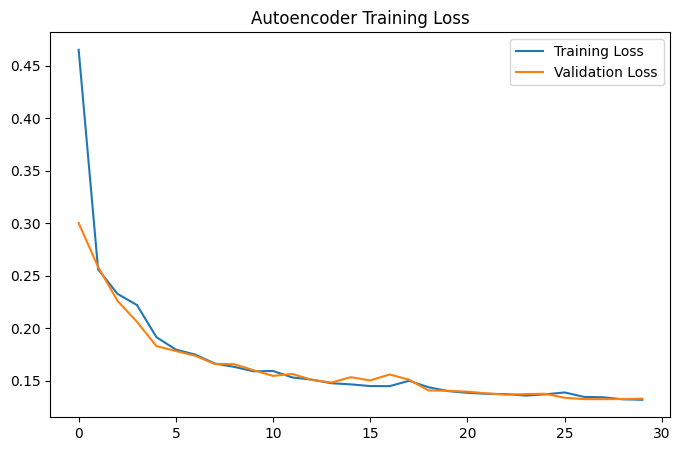

In [40]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.legend()

plt.title("Autoencoder Training Loss")

plt.show()

Compute Reconstruction Error

In [41]:
reconstructions = autoencoder.predict(X_scaled)

mse = np.mean(np.power(X_scaled - reconstructions, 2), axis=1)

df_sample["anomaly_score"] = mse

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step


In [58]:
feature_deviation = abs(X_scaled - reconstructions)

deviation_df = pd.DataFrame(
    feature_deviation,
    columns=X.columns
)

In [62]:
df_sample["top_feature"] = deviation_df.idxmax(axis=1)

In [69]:
anomalies = df_sample[df_sample["is_anomaly"] == True]

anomalies[[
    "MEMBER_ID",
    "AMOUNT",
    "txn_frequency",
    "CHANNEL",
    "RO_CODE",
    "anomaly_score",
    "top_feature"
]].head(20)

,MEMBER_ID,AMOUNT,txn_frequency,CHANNEL,RO_CODE,anomaly_score,top_feature
1,102660,2000.00,2,8,125139,0.353177,MERCHANT_ID
3,94357,500.00,1,4,100,0.489476,POINTS
16,7955,650.00,2,5,346384,0.319612,MERCHANT_ID
28,100245,2000.00,2,8,375326,0.593952,Unnamed: 0_x
30,136045,1000.00,4,5,273168,0.336979,SALES_AREA
37,138032,2700.00,2,5,106366,0.321597,Unnamed: 0_x
72,93264,500.00,2,5,352885,0.348647,TXN_DT_x
94,93690,3265.99,1,8,133649,0.336656,Unnamed: 0_x
133,123199,489.21,1,5,336721,0.428850,AO_DO
172,68723,853.04,1,5,125179,0.414902,TERMINAL_ID


Define Anomaly Threshold

In [42]:
threshold = np.percentile(mse, 95)

print("Threshold:", threshold)

df_sample["is_anomaly"] = df_sample["anomaly_score"] > threshold

Threshold: 0.30541710947571726


Visualize Anomaly Distribution

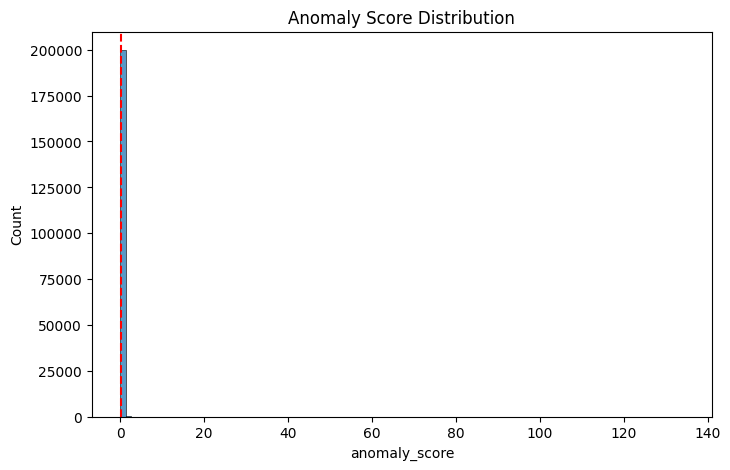

In [43]:
plt.figure(figsize=(8,5))

sns.histplot(df_sample["anomaly_score"], bins=100)

plt.axvline(threshold, color="red", linestyle="--")

plt.title("Anomaly Score Distribution")

plt.show()

Show Most Suspicious Transactions

In [44]:
frauds = df_sample.sort_values(
    "anomaly_score",
    ascending=False
)

frauds.head(20)

,Unnamed: 0_x,STATE_OFFICE,AO_DO,SALES_AREA,RO_NAME,RO_CODE,MERCHANT_ID,TXN_DT_x,TXN_NUM,CHANNEL,...,VEHICLE_MAKE,VEHICLE_MODEL,FUEL_TYPE,SUPPRESS_FAX_FLG,ON_BOARD_DT,TXN_DT_y,STATUS_CD,txn_frequency,anomaly_score,is_anomaly
45845,45845,20,102,762,5452,187411,4761,2025-12-25 07:12:47,136809,5,...,0,0,0,0,1706522502,2025-12-25 19:02:47,0,1,134.313241,True
162197,162197,5,5,10,803,112263,5423,2025-12-24 07:12:28,150435,5,...,0,0,0,0,1686027991,2025-12-24 19:28:28,0,1,110.026992,True
86428,86428,20,49,348,2038,184867,3484,2025-12-28 06:12:08,119547,5,...,0,0,0,0,1605172291,2025-12-28 18:10:08,0,1,95.373434,True
115538,115538,13,18,669,2407,199591,2484,2025-12-24 12:12:04,144480,5,...,0,0,0,0,1598663333,2025-12-24 12:28:04,0,1,92.872022,True
119108,119108,11,36,602,7842,125124,10977,2025-12-04 10:12:52,192064,8,...,0,0,0,0,1578290460,2025-12-04 10:21:52,0,1,67.817019,True
77466,77466,32,63,291,4939,190666,8545,2025-12-14 12:12:36,65446,5,...,0,0,0,0,1572696660,2025-12-14 12:16:36,0,1,67.537663,True
65637,65637,15,88,742,8684,141790,7535,2025-12-10 01:12:15,11583,5,...,0,0,0,0,1664442560,2025-12-10 13:30:15,0,1,58.991467,True
88726,88726,16,72,524,5719,100,11141,2025-12-16 12:12:15,4558,2,...,0,0,0,0,1765865535,2025-12-16 12:26:15,0,1,20.531740,True
15874,15874,16,72,524,5719,100,11141,2025-12-22 09:12:13,199912,2,...,0,0,0,0,1766376733,2025-12-22 09:49:13,0,1,20.529977,True
51147,51147,16,72,524,5719,100,11141,2025-12-26 03:12:36,199610,11,...,0,0,0,1,-9223372037,0,2,1,20.140880,True


Save Results

In [45]:
df_sample.to_csv("detected_anomalies.csv", index=False)

In [47]:
important_cols = [
    "MEMBER_ID",
    "TXN_NUM",
    "AMOUNT",
    "TRANSACTION_TYPE",
    "CHANNEL",
    "RO_CODE",
    "STATE_OFFICE",
    "txn_frequency",
    "anomaly_score",
    "is_anomaly"
]

In [49]:
anomaly_report = df_sample[important_cols]

anomaly_report.head(20)

,MEMBER_ID,TXN_NUM,AMOUNT,TRANSACTION_TYPE,CHANNEL,RO_CODE,STATE_OFFICE,txn_frequency,anomaly_score,is_anomaly
0,67666,168454,150.00,0,5,193960,11,2,0.239968,False
1,102660,196137,2000.00,0,8,125139,11,2,0.353177,True
2,128812,108372,1000.00,0,5,185672,26,3,0.091906,False
3,94357,813,500.00,0,4,100,16,1,0.489476,True
4,47342,49404,300.00,0,5,347188,11,1,0.183815,False
5,70192,99142,500.00,0,5,234159,13,2,0.062069,False
6,90212,171722,1500.00,0,5,127396,24,2,0.269282,False
7,121921,96651,3101.00,0,5,160505,7,1,0.082497,False
8,81090,67920,3113.19,0,5,186855,3,1,0.143256,False
9,137970,161118,950.00,0,5,335468,1,1,0.263064,False


In [54]:
feature_deviation = abs(X_scaled - reconstructions)

deviation_df = pd.DataFrame(
    feature_deviation,
    columns=X.columns
)

df_sample["top_feature"] = deviation_df.idxmax(axis=1)

In [72]:
anomalies.to_csv("fraud_explanations.csv", index=False)